# Grid search example with hyperoptax

In [1]:
import time

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training import train_state

from hyperoptax.bayesian import BayesianSearch
from hyperoptax.random import RandomSearch
from hyperoptax.spaces import LinearSpace, LogSpace

key = jax.random.PRNGKey(0)


In [2]:
# make a basic model
class Model(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        return nn.Dense(1)(x)


# make a basic dataset
key, key_data = jax.random.split(key, 2)
x = jax.random.uniform(key_data, (1000, 10))
y = 5 * x.mean(axis=1) ** 2 + 2
xtrain = x[:800]
ytrain = y[:800]
xtest = x[800:]
ytest = y[800:]


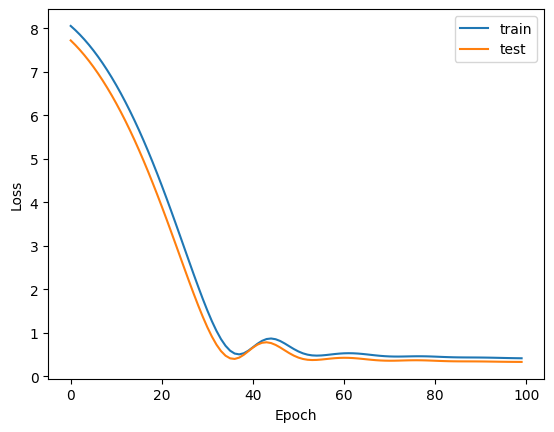

In [3]:
# end to end loop
def make_and_train_model(
    learning_rate, final_lr_pct, weight_decay=0.0001, n_epochs=100
):
    key = jax.random.PRNGKey(0)
    key, key_init = jax.random.split(key, 2)
    model = Model()
    # make a train state
    ts = train_state.TrainState.create(
        apply_fn=model.apply,
        params=model.init(key_init, jnp.zeros((10,))),
        tx=optax.adamw(
            learning_rate=optax.linear_schedule(
                init_value=learning_rate,
                end_value=final_lr_pct,
                transition_steps=n_epochs,
            ),
            weight_decay=weight_decay,
        ),
    )

    # learning loop
    def train_model(ts, n_epochs):
        def _train_step(ts, carry):
            def _loss(params):
                y_pred = ts.apply_fn(params, xtrain)
                return jnp.mean((y_pred - ytrain) ** 2)

            loss, grads = jax.value_and_grad(_loss)(ts.params)
            ts = ts.apply_gradients(grads=grads)
            return ts, loss

        def _eval_step(ts, carry):
            y_pred = ts.apply_fn(ts.params, xtest)
            return ts, jnp.mean((y_pred - ytest) ** 2)

        def _epoch_step(ts, carry):
            ts, loss_train = _train_step(ts, carry)
            ts, loss_eval = _eval_step(ts, carry)
            return ts, (loss_train, loss_eval)

        ts, losses = jax.lax.scan(_epoch_step, ts, None, n_epochs)
        return ts, losses

    return train_model(ts, n_epochs)


# Plot the losses
ts, losses = make_and_train_model(1e-3, 0.01, 0.0001, 100)
plt.plot(losses[0], label="train")
plt.plot(losses[1], label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [4]:
def wrapper(key, config):
    learning_rate = config.get("learning_rate", 1e-3)
    final_lr_pct = config.get("final_lr_pct", 0.01)
    weight_decay = config.get("weight_decay", 0.0001)
    # negate: we maximize by convention, so return negative loss
    return -make_and_train_model(learning_rate, final_lr_pct, weight_decay)[1][1][-1]


search_space = {
    "learning_rate": LogSpace(1e-4, 1e-2),
    "final_lr_pct": LinearSpace(0.01, 0.99),
}
n_iterations = 50

key, subkey = jax.random.split(key)
state, optimizer = RandomSearch.init(search_space)

start = time.time()
state, (params_hist, results_hist) = optimizer.optimize(
    state, subkey, wrapper, n_iterations
)
end = time.time()

best_idx = int(jnp.argmax(jnp.array([float(r.squeeze()) for r in results_hist])))
best_params = params_hist[best_idx]

print("Optimal params:", best_params)
print(f"Time taken: {end - start:.2f} seconds for {n_iterations} configs")
print("Optimal loss:", -float(results_hist[best_idx].squeeze()))

Optimal params: {'final_lr_pct': Array([0.87481517], dtype=float32), 'learning_rate': Array([0.00035055], dtype=float32)}
Time taken: 14.26 seconds for 50 configs
Optimal loss: 0.17405471205711365


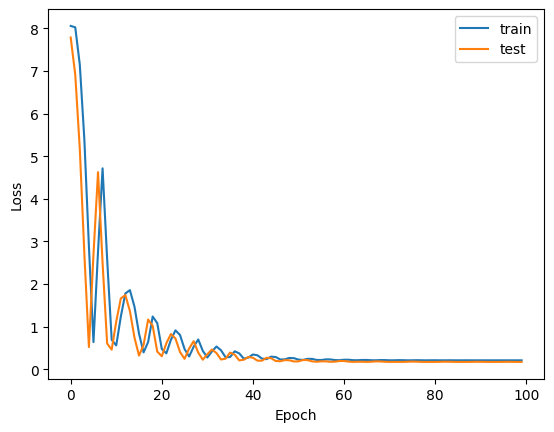

In [5]:
# Plot the losses for the best found hyperparameters
ts, losses = make_and_train_model(
    float(best_params["learning_rate"].squeeze()),
    float(best_params["final_lr_pct"].squeeze()),
    0.0001,
    100,
)
plt.plot(losses[0], label="train")
plt.plot(losses[1], label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Bayesian Optimization

For high dimensional spaces, that are hard to search with grid/random

In [ ]:
# Huge search space — Bayesian search finds good regions faster than random
search_space = {
    "learning_rate": LogSpace(1e-6, 1e-1),
    "final_lr_pct": LinearSpace(0.01, 0.99),
    "weight_decay": LogSpace(1e-6, 1e-1),
}
n_iterations = 100

key, subkey = jax.random.split(key)
state, optimizer = BayesianSearch.init(search_space, n_max=n_iterations)

start = time.time()
state, (params_hist, results_hist) = optimizer.optimize(
    state, subkey, wrapper
)
end = time.time()

best_idx = int(jnp.argmax(jnp.array([float(r.squeeze()) for r in results_hist])))
best_params = params_hist[best_idx]

print("Optimal params:", best_params)
print(f"Time taken: {end - start:.2f} seconds for {n_iterations} configs")
print("Optimal loss:", -float(results_hist[best_idx].squeeze()))


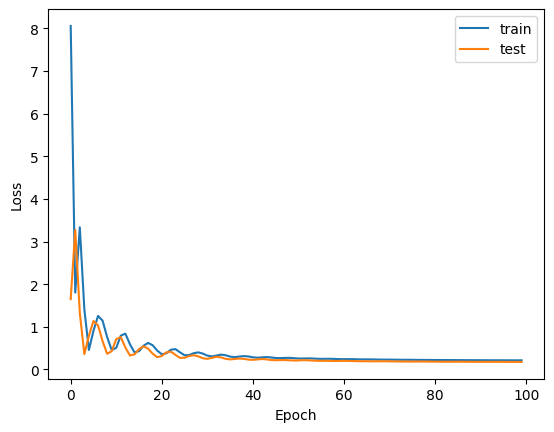

In [ ]:
# Plot the losses for the best found hyperparameters
ts, losses = make_and_train_model(
    float(best_params["learning_rate"].squeeze()),
    float(best_params["final_lr_pct"].squeeze()),
    float(best_params["weight_decay"].squeeze()),
    100,
)
plt.plot(losses[0], label="train")
plt.plot(losses[1], label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()